# Basic signals
Nesta atividades criaremos a nossa primeira **biblioteca de sinais digitais** com os sinais:

1. Delta: $\delta[n]$
2. Degrau: $u[n]$
3. Oscilação (periódico): $A \sin(\omega n + \phi)$
4. Exponencial
5. Aleatório (estocástico)


## Sinal delta, ou "impulso" - $\delta[n]$

<div style="text-align: center;">
    <img src="./figures/delta.png" alt="" width="500"/>
</div>


In [1]:
import numpy as np
import matplotlib.pyplot as plt

#import sys
#sys.path.append('/home/kuntur/Documents')
#from lib.myPlotLib import *

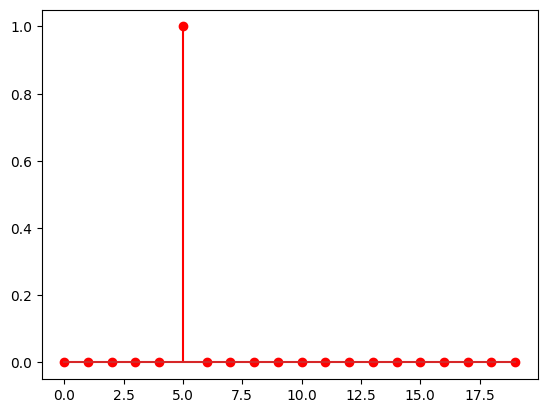

In [34]:
# 1. Sinal delta (v1.0) - Usando numpy
N     = 20
xn    = np.zeros(N)
k     = 5 # delay)
xn[k] = 1 # x[n-k]

# v2.0 - Usando listas
xn    = [0]*N
xn[k] = 1
xn    = np.array(xn)

# Vetor de amostras
n     = np.arange(N)

fig, ax = plt.subplots()
ax.stem(n, xn, 'r')
#figureFormat(ax, fig, tight=True)
plt.show()

## Sinal degrau - $u[n]$

<div style="text-align: center;">
    <img src="./figures/step.png" alt="" width="500"/>
</div>


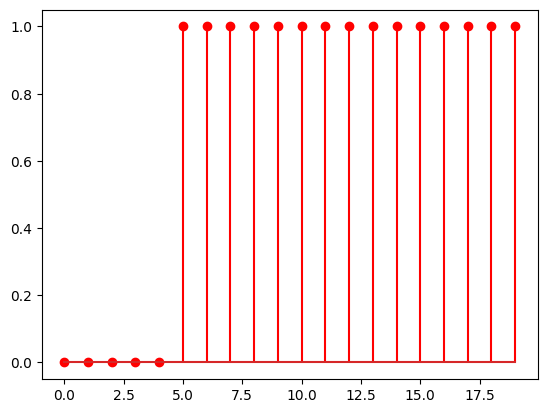

In [37]:
# 2. Degrau (v1.0) - Usando numpy
un      = np.zeros(N)
un[k:]  = 1

# v2.0 - Usando listas
un = [0]*k + [1]*(N-k)
un = np.array(un)

# Vetor de amostras
n  = np.arange(N)

fig, ax = plt.subplots()
ax.stem(n, un, 'r')
#figureFormat(ax, fig, tight=True)
plt.show()

## Sinal oscilatório, ou periódico - $A \sin(\omega n + \phi)$

<div style="text-align: center;">
    <img src="./figures/sine.png" alt="" width="500"/>
</div>


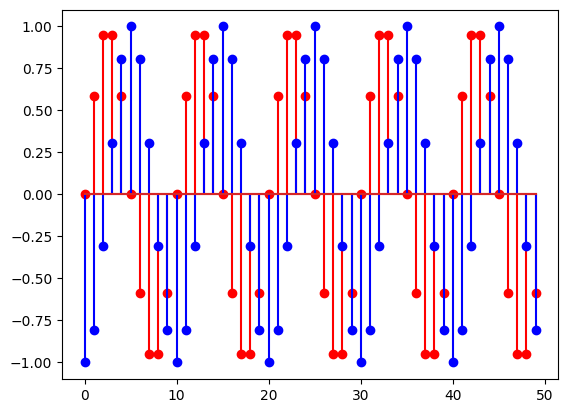

In [6]:
# 4. Sinal periodico
N  = 50 # numero de amostras
k  = 0 # delay
n  = np.arange(N) # vetor de amostras

A   = 1
P   = 10 # periodo do sinal
wo  = 2*np.pi/P # frequencia digital
phi = 0 # fase
xn  = A*np.sin(wo*n + phi)
yn  = A*np.sin(wo*n + phi + 3*np.pi/2) # + 3*np.pi/2)

# Plotagem
fig, ax = plt.subplots()
ax.stem(n, xn, 'ro')
ax.stem(n, yn, 'bd')
# plt.xlim([0, 20])
#figureFormat(ax, fig, tight=True)
plt.show()

## Sinal exponencial - $|a|^{n} u[n]$

<div style="text-align: center;">
    <img src="./figures/exp.png" alt="" width="500"/>
</div>


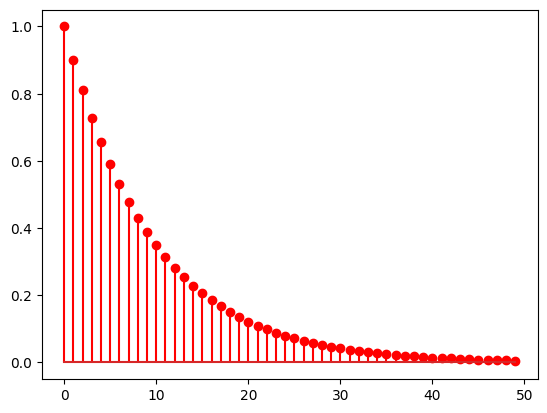

In [7]:
# 3. Exponencial
a  = 0.9
yn = a**n

fig, ax = plt.subplots()
ax.stem(n, yn, 'r')
#figureFormat(ax, fig, tight=True)
plt.show()

## Sinal aleatório - $x[n] = ?$

<div style="text-align: center;">
    <img src="./figures/random-Gaussian.png" alt="" width="500"/>
    <img src="./figures/random-uniform.png" alt="" width="500"/>
</div>


### Aleatório Gaussiano - $\mathcal{X} \sim \mathcal{N}(\mu, \sigma)$

<div style="text-align: center;">
    <img src="./figures/random-Gaussian-dist.png" alt="" width="500"/>
</div>


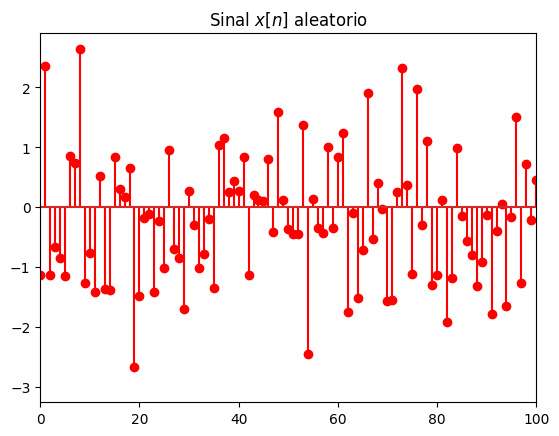

In [20]:
# 5. Sinal aleatorio (distribuicao Gaussiana)
N = 200
n  = np.arange(N) # vetor de amostras

xn = np.random.normal(mu, sigma, N) # Gaussiano (normal)

# Plot
fig, ax = plt.subplots(1)
ax.stem(n, xn, 'ro')
plt.xlim([0, 100])
ax.set_title(r'Sinal $x[n]$ aleatorio')
#figureFormat(ax, fig, tight=True)
plt.show()

Plote o **histograma** deste sinal.

**Dica:** Use `ax.hist`


In [22]:
help(ax.hist)

Help on method hist in module matplotlib.axes._axes:

hist(
    x,
    bins=None,
    *,
    range=None,
    density=False,
    weights=None,
    cumulative=False,
    bottom=None,
    histtype='bar',
    align='mid',
    orientation='vertical',
    rwidth=None,
    log=False,
    color=None,
    label=None,
    stacked=False,
    data=None,
    **kwargs
) method of matplotlib.axes._axes.Axes instance
    Compute and plot a histogram.

    This method uses `numpy.histogram` to bin the data in *x* and count the
    number of values in each bin, then draws the distribution either as a
    `.BarContainer` or `.Polygon`. The *bins*, *range*, *density*, and
    *weights* parameters are forwarded to `numpy.histogram`.

    If the data has already been binned and counted, use `~.bar` or
    `~.stairs` to plot the distribution::

        counts, bins = np.histogram(x)
        plt.stairs(counts, bins)

    Alternatively, plot pre-computed bins and counts using ``hist()`` by
    treating each bi

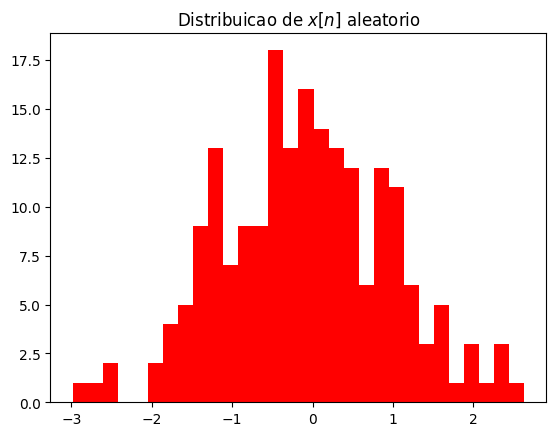

In [23]:
fig, ax = plt.subplots()
ax.hist(xn, 30, color='r')
ax.set_title(r'Distribuicao de $x[n]$ aleatorio')
#figureFormat(ax, fig, tight=True)
plt.show()

### Aleatório uniforme - $\mathcal{X} \sim \mathcal{U} \{a, b\}$

<div style="text-align: center;">
    <img src="./figures/random-uniform-dist.png" alt="" width="500"/>
</div>


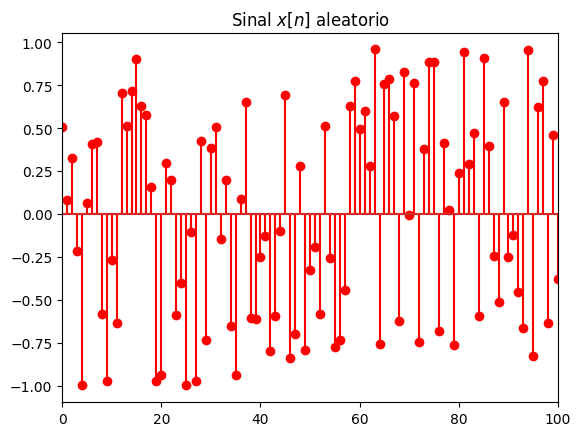

In [24]:
# 5. Sinal aleatorio (distribuicao uniforme)
N = 200
n  = np.arange(N) # vetor de amostras

xn = np.random.uniform(a, b, N) # uniforme

# Plot
fig, ax = plt.subplots(1)
ax.stem(n, xn, 'ro')
plt.xlim([0, 100])
ax.set_title(r'Sinal $x[n]$ aleatorio')
#figureFormat(ax, fig, tight=True)
plt.show()

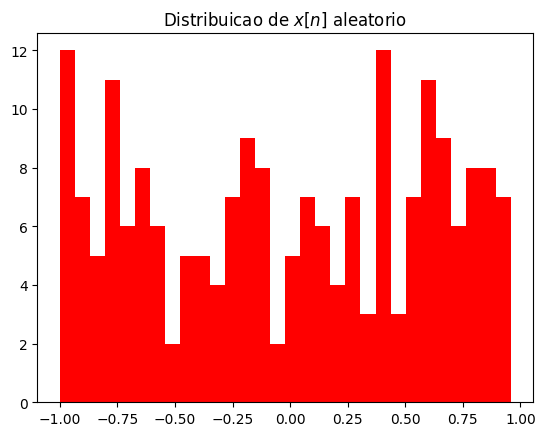

In [25]:
fig, ax = plt.subplots()
ax.hist(xn, 30, color='r')
ax.set_title(r'Distribuicao de $x[n]$ aleatorio')
#figureFormat(ax, fig, tight=True)
plt.show()

## Minha biblioteca de sinais básicos

In [49]:
def SIGNALgenerate(N=100, signal='delta', params=None):
    n = np.arange(N)

    if signal == 'delta':
        '''
        Delta (impulse)
          - k: shift (d[n - k])
        '''
        k = params.get('k', 0) if params else 0
        x = np.zeros(N)
        x[k] = 1

    if signal == 'step':
        '''
        Step
          - k: shift (u[n - k])
        '''
        k = params.get('k', 0) if params else 0
        x = np.zeros(N)
        x[k:] = 1

    if signal == 'exp':
        '''
        Exponential
          - a: base of exponential
          - k: shift (x[n - k])
        '''
        a = params.get('a', 0.9) if params else 0.9
        k = params.get('k', 0) if params else 0
        x = np.zeros(N)
        x[k:] = a**(n[k:] - k)

    if signal == 'osc':
        '''
        Oscillation
          - P: Period
          - phi: Phase
        '''
        P   = params.get('P', 10) if params else 10
        phi = params.get('phi', 0) if params else 0
        wo  = 2*np.pi/P
        x = np.sin(wo*n + phi)

    if signal == 'random':
        '''
        Random
        '''
        if params == 'uniform':
            '''
            Uniform
            '''
            x = np.random.uniform(-1, 1, N)
        else:
            '''
            Gaussian
            '''
            x = np.random.normal(0, 1, N)

    return np.array(x)

In [53]:
def SIGNALdelay(x, k):
    '''
    Slows a signal down by k samples
    '''

    result = np.zeros_like(x)
    result[n:] = x[:len(x)-n]

    return result

In [14]:
def SIGNALplot2(x):
    fig, ax = plt.subplots()
    ax.stem(x, 'r')
    # figureFormat(ax, fig, tight=True)
    plt.show()

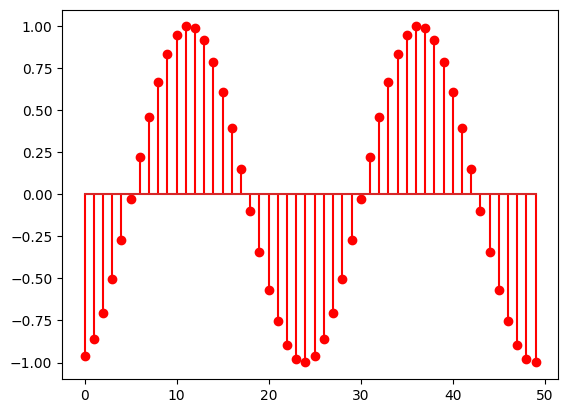

In [85]:
# Testando a biblioteca
SIGNALplot2(SIGNALgenerate(50, 'osc', {'P': 25, 'phi': 5}))